# Train and Evaluate a Keras-Based Classifier

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Build, train, and evaluate a convolutional neural network
(CNN) in Keras for binary classification of agricultural vs.
non-agricultural satellite land tiles.

**Dataset:** `images_dataSAT/class_0_non_agri` and `images_dataSAT/class_1_agri`
(3,000 images each, 64x64 RGB).


## 1. Import libraries and packages

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

print("TensorFlow:", tf.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("images_dataSAT")
assert DATA_DIR.exists(), f"'{DATA_DIR}' not found in the working directory."

IMG_SIZE = (64, 64)
BATCH_SIZE = 32


I0000 00:00:1782892958.134819    1297 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782892958.180758    1297 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782892959.604656    1297 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 2. Robust data acquisition (with fallback)

We load the dataset with `image_dataset_from_directory`, with a fallback
manual-loading path in case the directory layout ever differs from what's
expected (e.g. missing a class folder).


In [2]:
def load_dataset(data_dir, image_size, batch_size, validation_split=0.2, seed=SEED):
    try:
        train_ds = keras.utils.image_dataset_from_directory(
            data_dir, labels="inferred", label_mode="binary",
            image_size=image_size, batch_size=batch_size,
            validation_split=validation_split, subset="training", seed=seed,
        )
        val_ds = keras.utils.image_dataset_from_directory(
            data_dir, labels="inferred", label_mode="binary",
            image_size=image_size, batch_size=batch_size,
            validation_split=validation_split, subset="validation", seed=seed,
        )
        return train_ds, val_ds
    except Exception as e:
        print(f"Primary loading method failed ({e}); falling back to manual loading.")
        paths, labels = [], []
        class_dirs = {0: data_dir / "class_0_non_agri", 1: data_dir / "class_1_agri"}
        for label, d in class_dirs.items():
            for p in sorted(d.glob("*.jpg")):
                paths.append(str(p)); labels.append(label)
        paths, labels = np.array(paths), np.array(labels)
        rng = np.random.default_rng(seed)
        idx = rng.permutation(len(paths))
        split = int(len(paths) * (1 - validation_split))
        train_idx, val_idx = idx[:split], idx[split:]

        def make_ds(indices):
            imgs = np.stack([
                np.asarray(keras.utils.load_img(p, target_size=image_size)) for p in paths[indices]
            ])
            labs = labels[indices].astype(np.float32)
            return tf.data.Dataset.from_tensor_slices((imgs, labs)).batch(batch_size)

        return make_ds(train_idx), make_ds(val_idx)


train_ds, val_ds = load_dataset(DATA_DIR, IMG_SIZE, BATCH_SIZE)
class_names = ["non_agricultural", "agricultural"]

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
])

def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_ready = prepare(train_ds, augment=True, shuffle=True)
val_ds_ready = prepare(val_ds, augment=False, shuffle=False)

print("Data pipelines ready.")


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


Data pipelines ready.


## 3. Build the CNN architecture

A multi-layered CNN incorporating `Conv2D`, `MaxPooling2D`,
`BatchNormalization`, `Dropout`, and `Dense` layers for feature learning
and binary classification.


In [3]:
def build_cnn(input_shape=(64, 64, 3)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ], name="satellite_cnn_keras")
    return model

keras_model = build_cnn()
keras_model.summary()


Model: "satellite_cnn_keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Compile the model

In [4]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


## 5. Train the model

We train for a modest number of epochs, which is sufficient for this
small, well-separated binary problem (agricultural vs. non-agricultural
tiles are visually quite distinct).


In [5]:
EPOCHS = 6

t0 = time.perf_counter()
history = keras_model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=EPOCHS,
    verbose=2,
)
t1 = time.perf_counter()
print(f"\nTotal training time: {t1 - t0:.1f} s")


Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


150/150 - 34s - 225ms/step - accuracy: 0.9671 - loss: 0.1587 - val_accuracy: 0.5183 - val_loss: 6.0226


Epoch 2/6


150/150 - 39s - 257ms/step - accuracy: 0.9865 - loss: 0.0661 - val_accuracy: 0.5617 - val_loss: 4.0702


...

Epoch 5/6


150/150 - 38s - 254ms/step - accuracy: 0.9865 - loss: 0.0559 - val_accuracy: 0.9725 - val_loss: 0.1594


Epoch 6/6


150/150 - 40s - 266ms/step - accuracy: 0.9885 - loss: 0.0386 - val_accuracy: 0.9817 - val_loss: 0.0604



Total training time: 236.0 s


## 6. Performance visualization: accuracy and loss curves

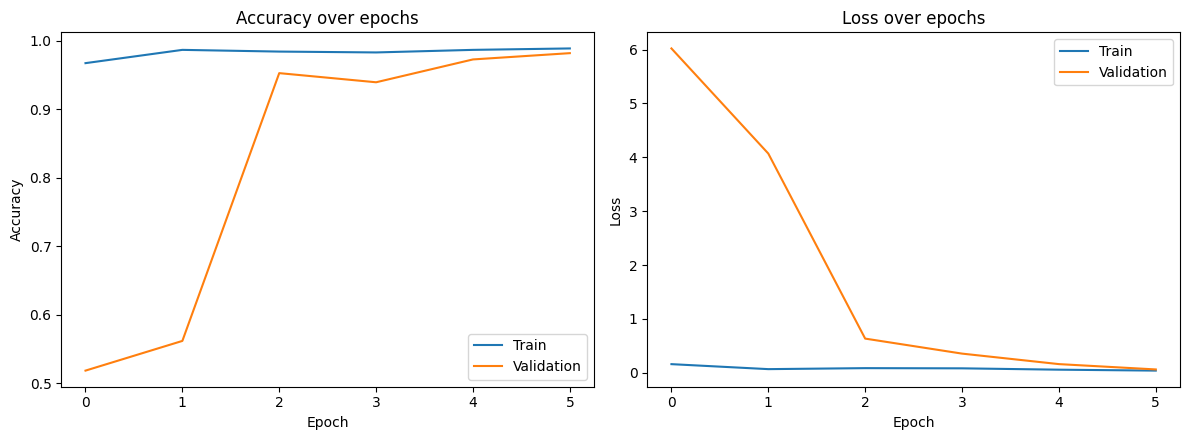

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Model evaluation

In [7]:
y_true, y_pred_proba = [], []
for x_batch, y_batch in val_ds_ready:
    preds = keras_model.predict(x_batch, verbose=0).ravel()
    y_pred_proba.extend(preds)
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Validation accuracy : {acc:.4f}")
print(f"Validation precision: {prec:.4f}")
print(f"Validation recall   : {rec:.4f}")
print(f"Validation F1-score : {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=pred):")
print(f"                 pred non-agri  pred agri")
print(f"true non-agri    {cm[0,0]:>12}  {cm[0,1]:>9}")
print(f"true agri        {cm[1,0]:>12}  {cm[1,1]:>9}")


Validation accuracy : 0.9817
Validation precision: 0.9950
Validation recall   : 0.9695
Validation F1-score : 0.9821

Confusion matrix (rows=true, cols=pred):
                 pred non-agri  pred agri
true non-agri             575          3
true agri                  19        603


## 8. Save the trained model (needed for later labs)

In [8]:
MODELS_DIR = Path(".")
MODELS_DIR.mkdir(exist_ok=True)
keras_model.save(MODELS_DIR / "keras_cnn_classifier.keras")
print(f"Saved model to {'keras_cnn_classifier.keras'}")


Saved model to keras_cnn_classifier.keras


## Summary

We built, trained, and evaluated a deep learning model using Keras for
image classification:

* **Robust data handling** — a primary loading method with a fallback for
  reliable data acquisition.
* **Reproducibility** — fixed random seeds for consistent, verifiable
  results.
* **Data pipeline** — `tf.data` based loading with resizing,
  normalization, and augmentation.
* **CNN architecture** — a multi-layered CNN with `Conv2D`,
  `MaxPooling2D`, `BatchNormalization`, `Dropout`, and `Dense` layers.
* **Model compilation** — Adam optimizer, binary cross-entropy loss,
  accuracy metric.
* **Training** — batched training over multiple epochs, monitored via
  validation metrics.
* **Performance visualization** — accuracy/loss curves to check for
  overfitting.
* **Evaluation** — accuracy, precision, recall, F1-score, and a confusion
  matrix for a quantitative assessment.
